# 🚗 Vietnamese Vehicle Classification — InceptionV3

## Hệ thống Phân loại Phương tiện Giao thông Việt Nam

In [1]:
import os
import json
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-29 03:15:33.546970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774754133.743217      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774754133.798602      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774754134.215798      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774754134.215845      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774754134.215848      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## ⚙️ Cấu hình Constants

In [ ]:
DATASET_NAME = "vietnamese-vehicle-5-classes"

KAGGLE_INPUT = f"/kaggle/input/datasets/hieu411/{DATASET_NAME.split('/')[-1]}"
TRAIN_DIR = os.path.join(KAGGLE_INPUT, "train")
VAL_DIR = os.path.join(KAGGLE_INPUT, "val")
TEST_DIR = os.path.join(KAGGLE_INPUT, "test")

OUTPUT_DIR = "/kaggle/working"

IMAGE_SIZE = (299, 299)
INPUT_SHAPE = (299, 299, 3)
NUM_CLASSES = 5
BATCH_SIZE = 32
RANDOM_SEED = 42

CLASS_NAMES = ["bicycle", "bus", "car", "motorcycle", "truck"]
CLASS_NAMES_VI = {
    "bicycle": "Xe đạp",
    "bus": "Xe buýt",
    "car": "Xe ô tô con",
    "motorcycle": "Xe máy",
    "truck": "Xe tải",
}

STAGE1_EPOCHS = 10
STAGE1_LR = 1e-3

STAGE2_EPOCHS = 40
STAGE2_LR = 1e-5
STAGE2_UNFREEZE_LAYERS = 50

LABEL_SMOOTHING = 0.05

EARLY_STOPPING_PATIENCE = 10
REDUCE_LR_PATIENCE = 5
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_MIN = 1e-7

BEST_MODEL_FILE = os.path.join(OUTPUT_DIR, "inception_v3_best.h5")
FINAL_MODEL_FILE = os.path.join(OUTPUT_DIR, "inception_v3_final.h5")
HISTORY_FILE = os.path.join(OUTPUT_DIR, "training_history.json")
CSV_LOG_FILE = os.path.join(OUTPUT_DIR, "training_log.csv")

print("✅ Đã cấu hình tất cả constants")
print(f"   Dataset path: {KAGGLE_INPUT}")
print(f"   Image size: {IMAGE_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Num classes: {NUM_CLASSES}")
print(f"   Label smoothing: {LABEL_SMOOTHING}")

✅ Đã cấu hình tất cả constants
   Dataset path: /kaggle/input/datasets/hieu411/vietnamese-vehicle-5-classes
   Image size: (299, 299)
   Batch size: 32
   Num classes: 5
   Label smoothing: 0.05


## 🎲 Random Seed (Reproducibility)

In [ ]:
def set_random_seed(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"✅ Random seed đã được đặt: {seed}")

set_random_seed() 

✅ Random seed đã được đặt: 42


## 📂 Kiểm tra Dữ liệu trên Kaggle

In [4]:
def kiem_tra_du_lieu() -> None:
    print("📂 Kiểm tra dữ liệu trên Kaggle...")
    print(f"   Input path: {KAGGLE_INPUT}")
    print()

    tong_anh = 0

    for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
        if not os.path.exists(split_dir):
            print(f"❌ KHÔNG TÌM THẤY: {split_dir}")
            print(f"   → Hãy kiểm tra lại tên dataset và cấu trúc zip!")
            return

        split_total = 0
        print(f"📁 {split_name}/")
        for class_name in sorted(os.listdir(split_dir)):
            class_dir = os.path.join(split_dir, class_name)
            if os.path.isdir(class_dir):
                so_anh = len([
                    f for f in os.listdir(class_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))
                ])
                ten_vn = CLASS_NAMES_VI.get(class_name, class_name)
                print(f"   ├── {class_name}/ ({ten_vn}): {so_anh} ảnh")
                split_total += so_anh
        print(f"   └── Tổng: {split_total} ảnh")
        tong_anh += split_total
        print()

    print(f"📊 Tổng toàn bộ: {tong_anh} ảnh")
    print("✅ Kiểm tra dữ liệu hoàn tất!")

kiem_tra_du_lieu()

📂 Kiểm tra dữ liệu trên Kaggle...
   Input path: /kaggle/input/datasets/hieu411/vietnamese-vehicle-5-classes

📁 train/
   ├── bicycle/ (Xe đạp): 3200 ảnh
   ├── bus/ (Xe buýt): 3200 ảnh
   ├── car/ (Xe ô tô con): 3200 ảnh
   ├── motorcycle/ (Xe máy): 2971 ảnh
   ├── truck/ (Xe tải): 3200 ảnh
   └── Tổng: 15771 ảnh

📁 val/
   ├── bicycle/ (Xe đạp): 400 ảnh
   ├── bus/ (Xe buýt): 400 ảnh
   ├── car/ (Xe ô tô con): 400 ảnh
   ├── motorcycle/ (Xe máy): 371 ảnh
   ├── truck/ (Xe tải): 400 ảnh
   └── Tổng: 1971 ảnh

📁 test/
   ├── bicycle/ (Xe đạp): 400 ảnh
   ├── bus/ (Xe buýt): 400 ảnh
   ├── car/ (Xe ô tô con): 400 ảnh
   ├── motorcycle/ (Xe máy): 372 ảnh
   ├── truck/ (Xe tải): 400 ảnh
   └── Tổng: 1972 ảnh

📊 Tổng toàn bộ: 19714 ảnh
✅ Kiểm tra dữ liệu hoàn tất!


## 📊 Data Pipeline (ImageDataGenerator + Augmentation)

In [ ]:
def tao_data_generators() -> tuple:
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        shear_range=0.1,
        fill_mode="nearest",
    )

    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
    )

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=RANDOM_SEED,
    )

    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False,
    )

    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False,
    )

    print(f"\n📊 Train:      {train_gen.samples} ảnh, {train_gen.num_classes} classes")
    print(f"📊 Validation: {val_gen.samples} ảnh, {val_gen.num_classes} classes")
    print(f"📊 Test:       {test_gen.samples} ảnh, {test_gen.num_classes} classes")
    print(f"📊 Class indices: {train_gen.class_indices}")

    batch_x, batch_y = next(train_gen)
    print(f"\n✅ Batch shape: X={batch_x.shape}, Y={batch_y.shape}")
    assert batch_x.shape[1:] == INPUT_SHAPE, f"Sai input shape! Expected {INPUT_SHAPE}"

    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = tao_data_generators()

Found 15771 images belonging to 5 classes.
Found 1971 images belonging to 5 classes.
Found 1972 images belonging to 5 classes.

📊 Train:      15771 ảnh, 5 classes
📊 Validation: 1971 ảnh, 5 classes
📊 Test:       1972 ảnh, 5 classes
📊 Class indices: {'bicycle': 0, 'bus': 1, 'car': 2, 'motorcycle': 3, 'truck': 4}

✅ Batch shape: X=(32, 299, 299, 3), Y=(32, 5)


## 🔍 Xem mẫu ảnh sau Augmentation

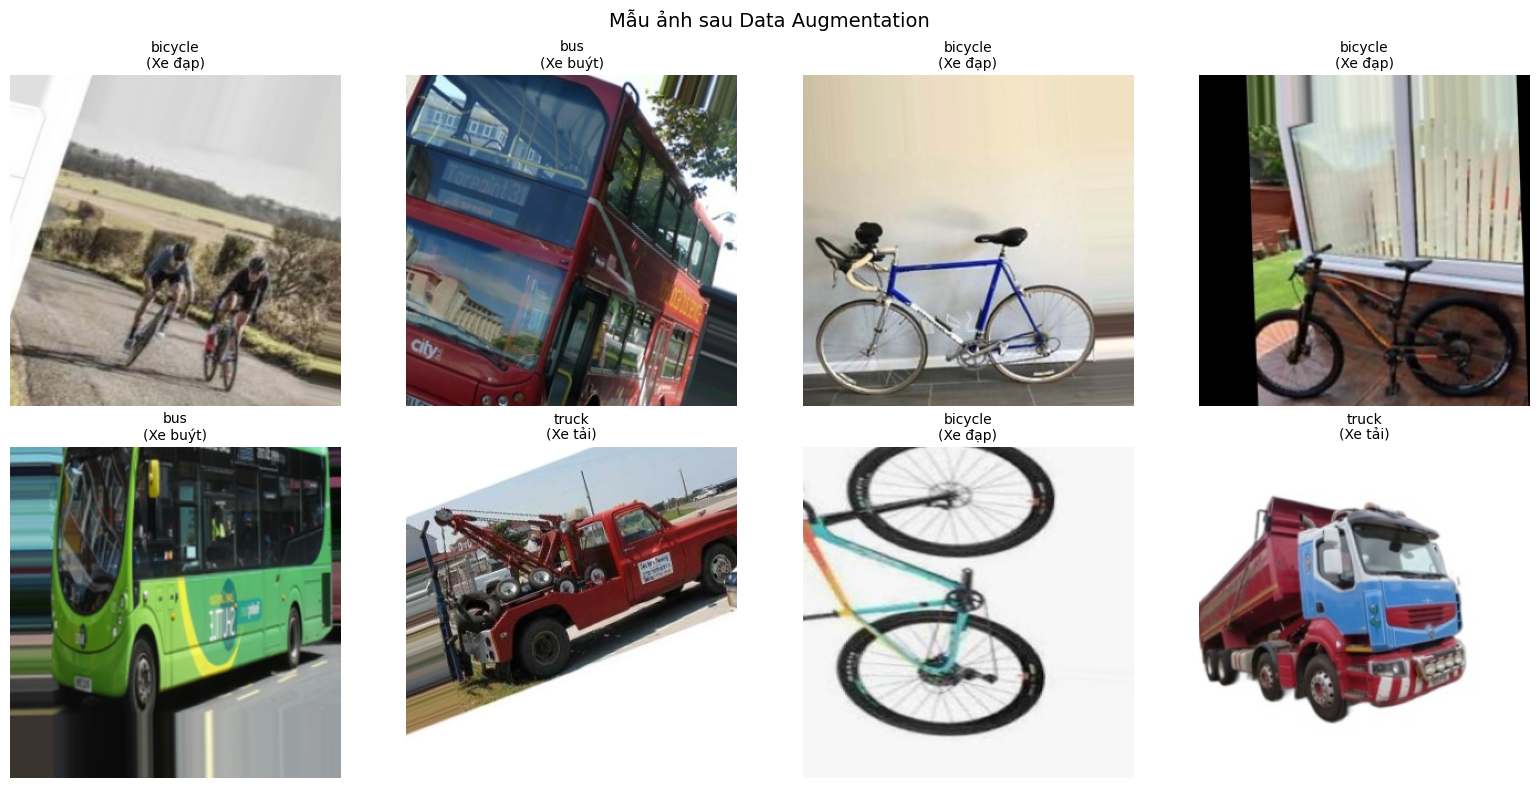

In [ ]:
def hien_thi_mau_augmented(train_gen, so_anh: int = 8) -> None:
    batch_x, batch_y = next(train_gen)
    class_labels = list(train_gen.class_indices.keys())

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        if i < so_anh and i < len(batch_x):
            img = np.clip((batch_x[i] + 1.0) / 2.0, 0.0, 1.0)
            ax.imshow(img)
            class_idx = np.argmax(batch_y[i])
            ten_class = class_labels[class_idx]
            ten_vn = CLASS_NAMES_VI.get(ten_class, ten_class)
            ax.set_title(f"{ten_class}\n({ten_vn})", fontsize=10)
            ax.axis("off")

    plt.suptitle("Mẫu ảnh sau Data Augmentation", fontsize=14)
    plt.tight_layout()
    plt.show()

hien_thi_mau_augmented(train_gen)

## 🧠 Model Architecture (InceptionV3 + Custom Head)

In [7]:
def tao_model() -> Model:
    base_model = InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = Dense(256, activation="relu", name="dense_256")(x)
    x = Dropout(0.5, name="dropout_05")(x)
    predictions = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    model = Model(
        inputs=base_model.input,
        outputs=predictions,
        name="VehicleClassifier_InceptionV3",
    )

    model.compile(
        optimizer=Adam(learning_rate=STAGE1_LR),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"],
    )

    tong_params = model.count_params()
    trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    non_trainable = tong_params - trainable

    print(f"📐 Model: {model.name}")
    print(f"   Tổng parameters:     {tong_params:,}")
    print(f"   Trainable params:    {trainable:,}")
    print(f"   Non-trainable params: {non_trainable:,}")
    print(f"   Output shape:        {model.output_shape}")
    print(f"   Label smoothing:     {LABEL_SMOOTHING}")

    return model

model = tao_model()

I0000 00:00:1774754172.799748      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774754172.806331      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
📐 Model: VehicleClassifier_InceptionV3
   Tổng parameters:     22,328,613
   Trainable params:    525,829
   Non-trainable params: 21,802,784
   Output shape:        (None, 5)
   Label smoothing:     0.05


In [8]:
model.summary()

Model: "VehicleClassifier_InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,328,613 (85.18 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

## 📞 Callbacks Configuration

In [9]:
def tao_callbacks() -> list:
    callbacks = [
        ModelCheckpoint(
            filepath=BEST_MODEL_FILE,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
        EarlyStopping(
            monitor="val_accuracy",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=REDUCE_LR_MIN,
            verbose=1,
        ),
        CSVLogger(
            CSV_LOG_FILE,
            append=True,
        ),
    ]

    print(f"✅ Đã tạo {len(callbacks)} callbacks:")
    print(f"   • ModelCheckpoint → {BEST_MODEL_FILE}")
    print(f"   • EarlyStopping (patience={EARLY_STOPPING_PATIENCE})")
    print(f"   • ReduceLROnPlateau (factor={REDUCE_LR_FACTOR}, patience={REDUCE_LR_PATIENCE})")
    print(f"   • CSVLogger → {CSV_LOG_FILE}")

    return callbacks

callbacks = tao_callbacks()

✅ Đã tạo 4 callbacks:
   • ModelCheckpoint → /kaggle/working/inception_v3_best.h5
   • EarlyStopping (patience=10)
   • ReduceLROnPlateau (factor=0.5, patience=5)
   • CSVLogger → /kaggle/working/training_log.csv


## 🚀 Stage 1: Freeze Base — Train Head Only

In [10]:
print("=" * 60)
print("🚀 STAGE 1: FREEZE BASE — TRAIN HEAD ONLY")
print(f"   Epochs: {STAGE1_EPOCHS} | LR: {STAGE1_LR}")
print("=" * 60)

history_stage1 = model.fit(
    train_gen,
    epochs=STAGE1_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1,
)

print(f"\n✅ Stage 1 hoàn thành!")
print(f"   Train accuracy: {history_stage1.history['accuracy'][-1]:.4f}")
print(f"   Val accuracy:   {history_stage1.history['val_accuracy'][-1]:.4f}")

🚀 STAGE 1: FREEZE BASE — TRAIN HEAD ONLY
   Epochs: 10 | LR: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774754185.715565     148 service.cc:152] XLA service 0x7e90b845b220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774754185.715614     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774754185.715619     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774754188.259126     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/493 ━━━━━━━━━━━━━━━━━━━━ 2:46:00 20s/step - accuracy: 0.3125 - loss: 1.7535

...

493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9335 - loss: 0.4216
Epoch 1: val_accuracy improved from -inf to 0.99594, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 432s 837ms/step - accuracy: 0.9336 - loss: 0.4215 - val_accuracy: 0.9959 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.9774 - loss: 0.3161
Epoch 2: val_accuracy improved from 0.99594 to 0.99645, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 318s 645ms/step - accuracy: 0.9774 - loss: 0.3161 - val_accuracy: 0.9964 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.9808 - loss: 0.3085
Epoch 3: val_accuracy did not improve from 0.99645
493/493 ━━━━━━━━━━━━━━━━━━━━ 320s 649ms/step - accuracy: 0.9809 - loss: 0.3085 - val_accuracy: 0.9959 - val_loss: 0.2479 - learning_rate: 0.0010
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9856 - loss: 0.3012
Epoch 4: val_accuracy improved from 0.99645 to 0.99696, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 316s 641ms/step - accuracy: 0.9856 - loss: 0.3012 - val_accuracy: 0.9970 - val_loss: 0.2435 - learning_rate: 0.0010
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.9835 - loss: 0.3008
Epoch 5: val_accuracy did not improve from 0.99696
493/493 ━━━━━━━━━━━━━━━━━━━━ 316s 641ms/step - accuracy: 0.9835 - loss: 0.3008 - val_accuracy: 0.9949 - val_loss: 0.2534 - learning_rate: 0.0010
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9858 - loss: 0.3001
Epoch 6: val_accuracy did not improve from 0.99696
493/493 ━━━━━━━━━━━━━━━━━━━━ 313s 635ms/step - accuracy: 0.9858 - loss: 0.3000 - val_accuracy: 0.9970 - val_loss: 0.2421 - learning_rate: 0.0010
Epoch 7/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9864 - loss: 0.2943
Epoch 7: val_accuracy improved from 0.99696 to 0.99746, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 313s 635ms/step - accuracy: 0.9864 - loss: 0.2943 - val_accuracy: 0.9975 - val_loss: 0.2398 - learning_rate: 0.0010
Epoch 8/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.9876 - loss: 0.2907
Epoch 8: val_accuracy did not improve from 0.99746
493/493 ━━━━━━━━━━━━━━━━━━━━ 320s 648ms/step - accuracy: 0.9876 - loss: 0.2907 - val_accuracy: 0.9970 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 9/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9878 - loss: 0.2920
Epoch 9: val_accuracy did not improve from 0.99746
493/493 ━━━━━━━━━━━━━━━━━━━━ 313s 635ms/step - accuracy: 0.9878 - loss: 0.2920 - val_accuracy: 0.9964 - val_loss: 0.2456 - learning_rate: 0.0010
Epoch 10/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9885 - loss: 0.2896
Epoch 10: val_accuracy did not improve from 0.99746
493/493 ━━━━━━━━━━━━━━━━━━━━ 316s 640ms/step - accuracy: 0.9885 - loss: 0.2896 - val_accuracy: 0.9975 - val_loss: 0.2411 - learning_rate: 0.0010
R

## 🚀 Stage 2: Fine-tune Top Layers

In [11]:
print("=" * 60)
print("🚀 STAGE 2: FINE-TUNE TOP LAYERS")
print(f"   Unfreeze: {STAGE2_UNFREEZE_LAYERS} layers | Epochs: {STAGE2_EPOCHS} | LR: {STAGE2_LR}")
print("=" * 60)

base_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

if base_model is not None:
    base_model.trainable = True
    for layer in base_model.layers[:-STAGE2_UNFREEZE_LAYERS]:
        layer.trainable = False
    print(f"   Base model: {base_model.name}")
    print(f"   Tổng layers: {len(base_model.layers)}")
    print(f"   Đã unfreeze: {STAGE2_UNFREEZE_LAYERS} layers cuối")
else:
    for layer in model.layers[-(STAGE2_UNFREEZE_LAYERS + 3):]:
        layer.trainable = True
    print("   ⚠️ Không tìm thấy sub-model, unfreeze trực tiếp top layers")

model.compile(
    optimizer=Adam(learning_rate=STAGE2_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)

trainable_s2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"   Trainable params (Stage 2): {trainable_s2:,}")

🚀 STAGE 2: FINE-TUNE TOP LAYERS
   Unfreeze: 50 layers | Epochs: 40 | LR: 1e-05
   ⚠️ Không tìm thấy sub-model, unfreeze trực tiếp top layers
   Trainable params (Stage 2): 7,256,773


In [12]:
history_stage2 = model.fit(
    train_gen,
    epochs=STAGE2_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1,
)

print(f"\n✅ Stage 2 hoàn thành!")
print(f"   Train accuracy: {history_stage2.history['accuracy'][-1]:.4f}")
print(f"   Val accuracy:   {history_stage2.history['val_accuracy'][-1]:.4f}")

Epoch 1/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9754 - loss: 0.3254
Epoch 1: val_accuracy did not improve from 0.99746
493/493 ━━━━━━━━━━━━━━━━━━━━ 357s 681ms/step - accuracy: 0.9754 - loss: 0.3254 - val_accuracy: 0.9970 - val_loss: 0.2433 - learning_rate: 1.0000e-05
Epoch 2/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.9846 - loss: 0.2982
Epoch 2: val_accuracy did not improve from 0.99746
493/493 ━━━━━━━━━━━━━━━━━━━━ 320s 648ms/step - accuracy: 0.9846 - loss: 0.2982 - val_accuracy: 0.9975 - val_loss: 0.2404 - learning_rate: 1.0000e-05
Epoch 3/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9879 - loss: 0.2915
Epoch 3: val_accuracy did not improve from 0.99746
493/493 ━━━━━━━━━━━━━━━━━━━━ 321s 651ms/step - accuracy: 0.9879 - loss: 0.2915 - val_accuracy: 0.9975 - val_loss: 0.2399 - learning_rate: 1.0000e-05
Epoch 4/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9884 - loss: 0.2852
Epoch 4: val_accuracy did not improve from 0.997

493/493 ━━━━━━━━━━━━━━━━━━━━ 325s 659ms/step - accuracy: 0.9929 - loss: 0.2765 - val_accuracy: 0.9980 - val_loss: 0.2376 - learning_rate: 1.0000e-05
Epoch 7/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.9938 - loss: 0.2735
Epoch 7: val_accuracy did not improve from 0.99797
493/493 ━━━━━━━━━━━━━━━━━━━━ 325s 658ms/step - accuracy: 0.9938 - loss: 0.2735 - val_accuracy: 0.9980 - val_loss: 0.2369 - learning_rate: 1.0000e-05
Epoch 8/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9935 - loss: 0.2710
Epoch 8: val_accuracy did not improve from 0.99797
493/493 ━━━━━━━━━━━━━━━━━━━━ 328s 665ms/step - accuracy: 0.9935 - loss: 0.2711 - val_accuracy: 0.9980 - val_loss: 0.2373 - learning_rate: 1.0000e-05
Epoch 9/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.9942 - loss: 0.2711
Epoch 9: val_accuracy did not improve from 0.99797
493/493 ━━━━━━━━━━━━━━━━━━━━ 323s 655ms/step - accuracy: 0.9942 - loss: 0.2711 - val_accuracy: 0.9980 - val_loss: 0.2355 - learning_rate

493/493 ━━━━━━━━━━━━━━━━━━━━ 322s 653ms/step - accuracy: 0.9941 - loss: 0.2706 - val_accuracy: 0.9985 - val_loss: 0.2367 - learning_rate: 1.0000e-05
Epoch 11/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9960 - loss: 0.2659
Epoch 11: val_accuracy did not improve from 0.99848
493/493 ━━━━━━━━━━━━━━━━━━━━ 312s 633ms/step - accuracy: 0.9960 - loss: 0.2659 - val_accuracy: 0.9980 - val_loss: 0.2367 - learning_rate: 1.0000e-05
Epoch 12/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9968 - loss: 0.2652
Epoch 12: val_accuracy did not improve from 0.99848
493/493 ━━━━━━━━━━━━━━━━━━━━ 321s 650ms/step - accuracy: 0.9968 - loss: 0.2652 - val_accuracy: 0.9985 - val_loss: 0.2366 - learning_rate: 1.0000e-05
Epoch 13/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9965 - loss: 0.2628
Epoch 13: val_accuracy improved from 0.99848 to 0.99899, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 318s 645ms/step - accuracy: 0.9965 - loss: 0.2628 - val_accuracy: 0.9990 - val_loss: 0.2359 - learning_rate: 1.0000e-05
Epoch 14/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9976 - loss: 0.2610
Epoch 14: val_accuracy improved from 0.99899 to 0.99949, saving model to /kaggle/working/inception_v3_best.h5


493/493 ━━━━━━━━━━━━━━━━━━━━ 317s 642ms/step - accuracy: 0.9976 - loss: 0.2610 - val_accuracy: 0.9995 - val_loss: 0.2348 - learning_rate: 1.0000e-05
Epoch 15/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9973 - loss: 0.2616
Epoch 15: val_accuracy did not improve from 0.99949
493/493 ━━━━━━━━━━━━━━━━━━━━ 317s 643ms/step - accuracy: 0.9973 - loss: 0.2616 - val_accuracy: 0.9985 - val_loss: 0.2347 - learning_rate: 1.0000e-05
Epoch 16/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.9975 - loss: 0.2616
Epoch 16: val_accuracy did not improve from 0.99949
493/493 ━━━━━━━━━━━━━━━━━━━━ 324s 657ms/step - accuracy: 0.9975 - loss: 0.2616 - val_accuracy: 0.9995 - val_loss: 0.2333 - learning_rate: 1.0000e-05
Epoch 17/40
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.9968 - loss: 0.2620
Epoch 17: val_accuracy did not improve from 0.99949
493/493 ━━━━━━━━━━━━━━━━━━━━ 315s 639ms/step - accuracy: 0.9968 - loss: 0.2620 - val_accuracy: 0.9990 - val_loss: 0.2339 - learnin

## 💾 Lưu Model & Training History

In [13]:
model.save(FINAL_MODEL_FILE)
print(f"💾 Đã lưu model cuối cùng: {FINAL_MODEL_FILE}")

full_history = {}
for key in history_stage1.history:
    full_history[key] = history_stage1.history[key] + history_stage2.history[key]

with open(HISTORY_FILE, "w") as f:
    serializable = {k: [float(v) for v in vals] for k, vals in full_history.items()}
    json.dump(serializable, f, indent=2)
print(f"📊 Đã lưu training history: {HISTORY_FILE}")

model_size_mb = os.path.getsize(FINAL_MODEL_FILE) / (1024 * 1024)
best_size_mb = os.path.getsize(BEST_MODEL_FILE) / (1024 * 1024)
print(f"\n📦 Kích thước model:")
print(f"   Final: {model_size_mb:.1f} MB")
print(f"   Best:  {best_size_mb:.1f} MB")

💾 Đã lưu model cuối cùng: /kaggle/working/inception_v3_final.h5
📊 Đã lưu training history: /kaggle/working/training_history.json

📦 Kích thước model:
   Final: 141.5 MB
   Best:  141.5 MB


## 📈 Training Curves (Accuracy & Loss)

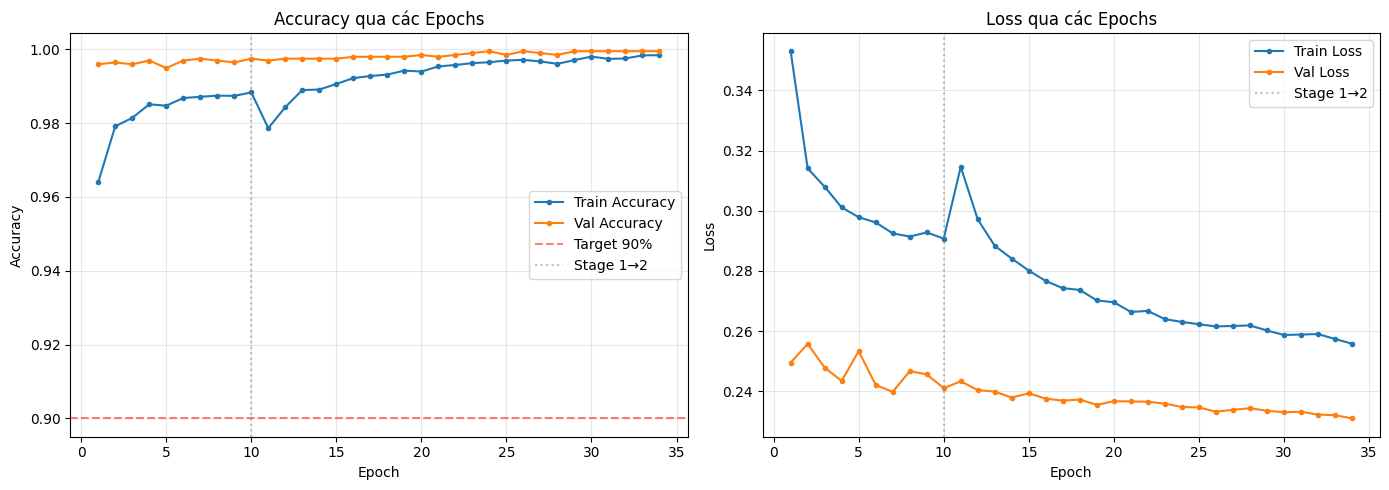

📈 Đã lưu training_curves.png


In [14]:
def ve_training_curves(history: dict) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history["accuracy"]) + 1)

    axes[0].plot(epochs_range, history["accuracy"], label="Train Accuracy", marker=".")
    axes[0].plot(epochs_range, history["val_accuracy"], label="Val Accuracy", marker=".")
    axes[0].axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="Target 90%")
    axes[0].axvline(x=STAGE1_EPOCHS, color="gray", linestyle=":", alpha=0.5, label="Stage 1→2")
    axes[0].set_title("Accuracy qua các Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history["loss"], label="Train Loss", marker=".")
    axes[1].plot(epochs_range, history["val_loss"], label="Val Loss", marker=".")
    axes[1].axvline(x=STAGE1_EPOCHS, color="gray", linestyle=":", alpha=0.5, label="Stage 1→2")
    axes[1].set_title("Loss qua các Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
    plt.show()
    print("📈 Đã lưu training_curves.png")

ve_training_curves(full_history)

## 📊 Đánh giá Model trên Test Set

In [15]:
def danh_gia_model(model: Model, test_gen) -> dict:
    print("=" * 60)
    print("📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET")
    print("=" * 60)

    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f"\n🎯 Test Loss:     {test_loss:.4f}")
    print(f"🎯 Test Accuracy: {test_acc:.4f} ({test_acc * 100:.1f}%)")

    if test_acc >= 0.9:
        print("✅ ĐẠT MỤC TIÊU > 90%!")
    else:
        print(f"⚠️  Chưa đạt mục tiêu 90% (thiếu {(0.9 - test_acc) * 100:.1f}%)")

    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    print("\n📋 Classification Report:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=class_labels))

    return {
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "y_true": y_true,
        "y_pred": y_pred,
        "class_labels": class_labels,
    }

eval_results = danh_gia_model(model, test_gen)

📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET

🎯 Test Loss:     0.2359
🎯 Test Accuracy: 0.9975 (99.7%)
✅ ĐẠT MỤC TIÊU > 90%!

📋 Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     bicycle       1.00      0.99      1.00       400
         bus       1.00      1.00      1.00       400
         car       1.00      1.00      1.00       400
  motorcycle       0.99      1.00      1.00       372
       truck       1.00      0.99      1.00       400

    accuracy                           1.00      1972
   macro avg       1.00      1.00      1.00      1972
weighted avg       1.00      1.00      1.00      1972



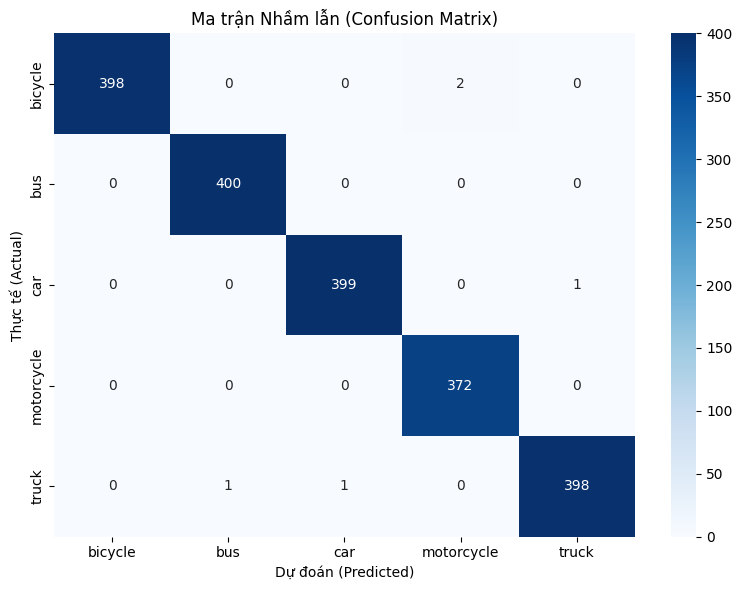

📊 Đã lưu confusion_matrix.png


In [18]:
def ve_confusion_matrix(y_true, y_pred, class_labels: list) -> None:
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.title("Ma trận Nhầm lẫn (Confusion Matrix)")
    plt.xlabel("Dự đoán (Predicted)")
    plt.ylabel("Thực tế (Actual)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()
    print("📊 Đã lưu confusion_matrix.png")

ve_confusion_matrix(
    eval_results["y_true"],
    eval_results["y_pred"],
    eval_results["class_labels"],
)

In [19]:
eval_save = {
    "test_loss": eval_results["test_loss"],
    "test_accuracy": eval_results["test_accuracy"],
    "classification_report": classification_report(
        eval_results["y_true"],
        eval_results["y_pred"],
        target_names=eval_results["class_labels"],
        output_dict=True,
    ),
    "confusion_matrix": confusion_matrix(
        eval_results["y_true"],
        eval_results["y_pred"],
    ).tolist(),
}

eval_file = os.path.join(OUTPUT_DIR, "evaluation_results.json")
with open(eval_file, "w") as f:
    json.dump(eval_save, f, indent=2, ensure_ascii=False)

print(f"💾 Đã lưu kết quả evaluation: {eval_file}")

💾 Đã lưu kết quả evaluation: /kaggle/working/evaluation_results.json
